# Precipitation (Part 1) - Climatology, Time Series and Hovmoller

## Model Inset

### Global Importation

In [1]:
# Shape modules 
from collections import defaultdict

# Computational modules 
import matplotlib.pyplot as plt
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed


### Load Raw Data (Ensemble Pre-Interpolation)

In [2]:
# Ensemble r1i1p1f1
model = 'UKESM1-0-LL'
model_short = 'UKESM'
path_figure = f"/home/users/alvin_ch/figures/Multi-model/{model_short}/Precip/"
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Precip/"


path = f"/home/users/speatier/DATA/TIPMIP/{model}/"
Table_ID = 'Amon'
esm_var = 'esm-hist'
config_1 = 'r1i1p1f1'
var = 'pr'
sub1 = 'gn'
sub2 = 'v20240619'
file_list_1 = ['pr_Amon_UKESM1-2-LL_esm-hist_r1i1p1f1_gn_185001-194912',
               'pr_Amon_UKESM1-2-LL_esm-hist_r1i1p1f1_gn_195001-201412']

files_ens_1 = {}
filetype = '.nc'
for expe in tqdm(file_list_1):
    path_tmp = (f"{path}{esm_var}/{config_1}/{Table_ID}/{var}/{sub1}/{sub2}/{expe}{filetype}")
    files_ens_1[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:02<00:00,  1.05s/it]


In [3]:
# Ensemble r2i1p1f1
config_2 = 'r2i1p1f1'
sub3 = 'v20241203'
file_list_2 = ['pr_Amon_UKESM1-2-LL_esm-hist_r2i1p1f1_gn_185001-194912',
               'pr_Amon_UKESM1-2-LL_esm-hist_r2i1p1f1_gn_195001-201412']

files_ens_2 = {}
for expe in tqdm(file_list_2):
    path_tmp = (f"{path}{esm_var}/{config_2}/{Table_ID}/{var}/{sub1}/{sub3}/{expe}{filetype}")
    files_ens_2[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 11.62it/s]


In [4]:
# Ensemble r3i1p1f1
config_3 = 'r3i1p1f1'
sub4 = 'v20241211'
file_list_3 = ['pr_Amon_UKESM1-2-LL_esm-hist_r3i1p1f1_gn_185001-194912',
               'pr_Amon_UKESM1-2-LL_esm-hist_r3i1p1f1_gn_195001-201412']

files_ens_3 = {}
for expe in tqdm(file_list_3):
    path_tmp = (f"{path}{esm_var}/{config_3}/{Table_ID}/{var}/{sub1}/{sub4}/{expe}{filetype}")
    files_ens_3[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00,  6.21it/s]


In [5]:
config_4 = 'r4i1p1f1'
sub5 = 'v20250107'
file_list_4 = ['pr_Amon_UKESM1-2-LL_esm-hist_r4i1p1f1_gn_185001-194912',
               'pr_Amon_UKESM1-2-LL_esm-hist_r4i1p1f1_gn_195001-201412']

files_ens_4 = {}
for expe in tqdm(file_list_4):
    path_tmp = (f"{path}{esm_var}/{config_4}/{Table_ID}/{var}/{sub1}/{sub5}/{expe}{filetype}")
    files_ens_4[expe] = xr.open_mfdataset(path_tmp, combine='by_coords', use_cftime=True)

100%|█████████████████████████████| 2/2 [00:00<00:00, 12.63it/s]


### Merge Pre-Interpolated Data

In [6]:
# Merge files of the same ensemble together.
# Implementation
def two_files_merge(files_dict, file_list, ensemble_member):
    ds1 = files_dict[file_list[0]]
    ds2 = files_dict[file_list[1]]
    merged = xr.concat([ds1, ds2], dim="time")
    merged = merged.compute()
    merged.to_netcdf(f"{path_files}/{ensemble_member}_time_merged.nc")
    merged.close()

In [7]:
# r1i1p1f1
# two_files_merge(files_ens_1, file_list_1, 'r1i1p1f1')

# r2i1p1f1
# two_files_merge(files_ens_2, file_list_2, 'r2i1p1f1')

# r3i1p1f1
# two_files_merge(files_ens_3, file_list_3, 'r3i1p1f1')

# r4i1p1f1
# two_files_merge(files_ens_4, file_list_4, 'r4i1p1f1')

### Load Interpolated Data

In [8]:
path_files = f"/home/users/alvin_ch/files/Multi-model/{model_short}/Precip/"
filename = "interpolated_obs_grid.nc"
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

interpolated_model_files = {}

for ens in ensemble_members:
    interpolated_model_files[ens] = xr.open_mfdataset(f'{path_files}{ens}_{filename}', combine='by_coords', use_cftime=True)

### Filter Ensemble Data (Climatology)

In [9]:
# Now we are interested in the same period as what we have in the observations.
# Period 1979-2014.
# We are only looking at ensemble r1p1i1f1 for climatology.
time_filtered_ens = {}

for ens in ensemble_members:
    time_filtered_ens[ens] = interpolated_model_files[ens].sel(time=slice("1979-01-01", "2015-01-01"))
    time_filtered_ens[ens] *= 86400

print("Start:", time_filtered_ens[ensemble_members[0]].time.min().values)
print("End:", time_filtered_ens[ensemble_members[0]].time.max().values)
print("Number of time steps:", time_filtered_ens[ensemble_members[0]].time.size)

Start: 1979-01-16 00:00:00
End: 2014-12-16 00:00:00
Number of time steps: 432


In [10]:
# Check unit Conversion
# Converted precipitation from kg m⁻² s⁻¹ to mm/day
ds = time_filtered_ens[ensemble_members[0]]
print(ds['pr'].values[:2])

[[[0.12758222 0.10969746 0.10829124 ... 0.12171717 0.1253801  0.12970419]
  [0.11629204 0.12142039 0.12498142 ... 0.09626419 0.09679327 0.10955632]
  [0.14171085 0.12462636 0.09429074 ... 0.10510474 0.10180674 0.10287374]
  ...
  [0.09270998 0.09070669 0.09063374 ... 0.1874747  0.13638665 0.10205264]
  [0.18210024 0.18424635 0.18725039 ... 0.18114926 0.18007131 0.18072708]
  [0.25666234 0.2588291  0.2604369  ... 0.24842383 0.25153407 0.25421005]]

 [[0.13095662 0.1299643  0.12844531 ... 0.13309114 0.13250877 0.13127987]
  [0.16071281 0.16338103 0.1647535  ... 0.15480442 0.15644735 0.1581018 ]
  [0.22346559 0.2184268  0.21270144 ... 0.22805172 0.22874549 0.22769608]
  ...
  [1.5001417  1.4277018  1.3618201  ... 1.5032634  1.4985906  1.6059375 ]
  [0.9121067  0.90120107 0.89485925 ... 0.9705592  0.9385446  0.91759956]
  [0.64660925 0.64208853 0.63672054 ... 0.65673894 0.6547202  0.65138376]]]


### Implementation 1a (Seasonal Mean, Over Time)

In [11]:
def compute_seasonal_average_customed_MJJAS(data):

    # Keep only May–September
    data_mjjas = data.sel(time=data['time.month'].isin([5, 6, 7, 8, 9]))

    # Average over time
    seasonal_avg = data_mjjas.mean(dim='time')
    return seasonal_avg

def seasonal_average_over_years_customed_MJJAS(data) :
    year_list_tmp = data.groupby('time.year').mean()
    year_list = year_list_tmp['year'].values[:-1]
    avg_list = []

    for y in year_list:
        data_1yr = data.sel(time=slice(str(y), str(y)))
        avg = compute_seasonal_average_customed_MJJAS(data_1yr)
        avg_list.append(avg)

    # Concatenate in new Xarray
    # Create labeled coordinate array for the new dimension
    year_coord = xr.DataArray(year_list, dims='year')

    # Concatenate
    combined = xr.concat(avg_list, dim=year_coord)
    return combined

In [12]:
seas = 'MJJAS'
seas_avg_model = {}
ensemble_members = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1']

for expe in ensemble_members:
    data = time_filtered_ens[expe]
    seas_avg_model[expe] = seasonal_average_over_years_customed_MJJAS(data)

### Compute Ensemble Mean

In [13]:
def compute_ensemble_mean(ensemble_list, data_dict, variable='pr'):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [14]:
climatology_ens_mean = compute_ensemble_mean(ensemble_members, seas_avg_model)
climatology_ens_mean

<xarray.DataArray 'pr' (year: 35, latitude: 72, longitude: 144)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(35, 72, 144), dtype=float32, chunksize=(1, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * year       (year) int64 280B 1979 1980 1981 1982 ... 2010 2011 2012 2013

### Implementation 1b (Climatology Map)

In [15]:
def plot_map_WAM (data, vmin, vmax, cbar_label, palette,lonmin, lonmax, latmin, 
                 latmax, title, Save, filename) :
    
    fig = plt.figure(figsize=(10,10), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=-30))

    # Extract original lat/lon
    lon_orig = data['longitude'].values
    lat = data['latitude'].values

    # Add cyclic point to data
    data_cyclic, lon_cyclic = add_cyclic_point(data, coord=lon_orig, axis=-1)

    # Create 2D grids
    lon2d, lat2d = np.meshgrid(lon_cyclic, lat)

    levels = np.linspace(0, 14, 25)
    
    # Plot the filled contours
    contour = ax.contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=palette)
    
    mm = ax.pcolormesh(lon2d, lat2d, data_cyclic,
                       vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(),
                       cmap=palette)
    
    # Set the map's extent (to zoom into the North Atlantic region)
    ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.coastlines()
    ax.gridlines(draw_labels=True)
        
    # Colorbar
    cbar = fig.colorbar(contour, ax=ax, orientation='horizontal', pad=0.02, fraction=0.4)
    cbar.ax.tick_params(labelsize=15) 
    cbar.set_label(label=cbar_label, fontsize=15)

    # Title
    plt.title(title, fontsize=15)

    # Save if requested
    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)

    plt.show()

## Observations Inset

### Load Data

In [16]:
# Load observations
obs_gen = 'GPCP'
filename = 'gpcp_v02r03_monthly_197901_202312.nc'
obs_path = f"/home/users/speatier/DATA/Obs/{var}/{obs_gen}/{filename}"
obs_file = xr.open_mfdataset(obs_path, combine='by_coords', use_cftime=True)

# Data is already in mm per day.
# No unit conversion required.
obs_file

<xarray.Dataset> Size: 45MB
Dimensions:         (time: 540, bnds: 2, longitude: 144, latitude: 72)
Coordinates:
  * time            (time) float64 4kB 1.979e+07 1.979e+07 ... 2.023e+07
  * longitude       (longitude) float32 576B 1.25 3.75 6.25 ... 356.2 358.8
  * latitude        (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds       (time, bnds) float64 9kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    longitude_bnds  (longitude, bnds) float32 1kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    latitude_bnds   (latitude, bnds) float32 576B dask.array<chunksize=(72, 2), meta=np.ndarray>
    precip          (time, latitude, longitude) float32 22MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
    precip_error    (time, latitude, longitude) float32 22MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
Attributes: (12/47)
    CDI:                        Climate Data Interface version 2.0.5 (https:/...
    source:                     oc.197901.sg
    institution:                ACADEMIC > UMD/ESSIC > Earth System Science I...
    Conventions:                CF-1.6, ACDD 1.3
    title:                      Global Precipitation Climatatology Project (G...
    references:                 Huffman et al. 1997, http://dx.doi.org/10.117...
    ...                         ...
    product_version:            v23rB1
    platform:                   NOAA POES (Polar Orbiting Environmental Satel...
    sensor:                     AVHRR>Advanced Very High Resolution Radiometer
    spatial_resolution:         2.5 degree
    comment:                    Processing computer: eagle2.umd.edu
    CDO:                        Climate Data Operators version 2.0.5 (https:/...

In [17]:
# Now we are interested in the same period as what we have in the observations.
# And that is 1979-2014.
filtered_obs = obs_file.sel(time=slice("1979-01-01", "2015-01-01"))

print("Start:", filtered_obs.time.min().values)
print("End:", filtered_obs.time.max().values)
print("Number of time steps:", filtered_obs.time.size)

Start: 19790101.0
End: 20141201.0
Number of time steps: 432


### Implementation 2a (Seasonal Mean)

In [18]:
# Similar function.
# Tweaked due to different variable names.
def seasonal_average_over_years_MJJAS_obs(data):

    # Convert numeric time into datetime.
    time_str = data.time.values.astype(str)
    dates = pd.to_datetime([x.split('.')[0] for x in time_str], format='%Y%m%d')
    data = data.assign_coords(time=dates)
    
    # Select May-September
    data_mjjas = data.sel(time=data.time.dt.month.isin([5, 6, 7, 8, 9]))

    # Create annual MJJAS averages
    seasonal_avg = data_mjjas.groupby('time.year').mean('time')
    return seasonal_avg

In [19]:
seas = 'MJJAS'
seas_avg_obs = {}
obs_list = ['obs']

for expe in obs_list:
    obs_data = filtered_obs
    seas_avg_obs = seasonal_average_over_years_MJJAS_obs(obs_data)

### Implementation 2b (Climatology Map)

In [20]:
# Similarly, tweaked version of plot implementation.
def plot_map_WAM_obs (data, vmin, vmax, cbar_label, palette,lonmin, lonmax, latmin, 
                 latmax, title, Save, filename) :
    
    fig = plt.figure(figsize=(10,10), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=-30))

    # Extract original lat/lon
    lon_orig = data['longitude'].values
    lat = data['latitude'].values

    # Add cyclic point to data
    data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=1)

    # Create 2D grids
    lon2d, lat2d = np.meshgrid(lon_cyclic, lat)

    levels = np.linspace(0, 14, 25)
    
    # Plot the filled contours
    contour = ax.contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=palette)
    
    mm = ax.pcolormesh(lon2d, lat2d, data_cyclic,
                       vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(),
                       cmap=palette)
    
    # Set the map's extent (to zoom into the North Atlantic region)
    ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.coastlines()
    ax.gridlines(draw_labels=True)
        
    # Colorbar
    cbar = fig.colorbar(contour, ax=ax, orientation='horizontal', pad=0.02, fraction=0.4)
    cbar.ax.tick_params(labelsize=15) 
    cbar.set_label(label=cbar_label, fontsize=15)

    # Title
    plt.title(title, fontsize=15)

    # Save if requested
    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)

    plt.show()

## Bias Inset

### Seasonal Mean Over Time

In [21]:
# Compute seasonal average over time for interpolated model outputs.
climatology_ens_mean

<xarray.DataArray 'pr' (year: 35, latitude: 72, longitude: 144)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(35, 72, 144), dtype=float32, chunksize=(1, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * year       (year) int64 280B 1979 1980 1981 1982 ... 2010 2011 2012 2013

In [22]:
# Seasonal average over time for observations
seas_avg_obs.data_vars

Data variables:
    time_bnds       (year, bnds) float64 576B dask.array<chunksize=(1, 2), meta=np.ndarray>
    precip          (year, latitude, longitude) float32 1MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
    precip_error    (year, latitude, longitude) float32 1MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
    longitude_bnds  (year, longitude, bnds) float32 41kB dask.array<chunksize=(36, 144, 2), meta=np.ndarray>
    latitude_bnds   (year, latitude, bnds) float32 21kB dask.array<chunksize=(36, 72, 2), meta=np.ndarray>

### Implementation 3a (Student t-Test)

In [23]:
def ttest_NO_bootstrap_bias(data_scen, data_piCTL):
    n_scen = data_scen.shape[0]
    n_ctl = data_piCTL.shape[0]

    # Make sure they have the same dimensions.
    if n_scen != n_ctl:
        raise TypeError('Sample sizes have different dimensions.')

    t_stat, p_value = ttest_ind(data_scen.values, data_piCTL.values, axis=0, equal_var=False)

    lat_name = [c for c in data_scen.coords if 'lat' in c.lower()][0]
    lon_name = [c for c in data_scen.coords if 'lon' in c.lower()][0]
    
    # Create an Xarray
    p_empirical_xr = xr.DataArray(
                p_value,
                dims=[lat_name, lon_name],
                coords={lat_name: data_scen[lat_name], lon_name: data_scen[lon_name]},
                name="p_value"
                )

    # Assign a name to your DataArray
    p_empirical_xr.name = "p_value"

    # Convert it to a Dataset (NetCDF requires a Dataset format)
    ds = p_empirical_xr.to_dataset()

    return ds

### Compute Bias

In [24]:
# Compute anomalies.  
common_years = np.intersect1d(seas_avg_obs['year'], climatology_ens_mean['year'])
obs_aligned = seas_avg_obs.sel(year=common_years)
int_aligned = climatology_ens_mean.sel(year=common_years)

bias_compute = int_aligned - obs_aligned['precip']
bias_compute

<xarray.DataArray (year: 35, latitude: 72, longitude: 144)> Size: 1MB
dask.array<sub, shape=(35, 72, 144), dtype=float32, chunksize=(1, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * year       (year) int64 280B 1979 1980 1981 1982 ... 2010 2011 2012 2013

### Statistical Significance

In [25]:
time_filtered_ens[ensemble_members[0]]

<xarray.Dataset> Size: 18MB
Dimensions:         (time: 432, longitude: 144, latitude: 72, bnds: 2)
Coordinates:
  * time            (time) object 3kB 1979-01-16 00:00:00 ... 2014-12-16 00:0...
  * longitude       (longitude) float32 576B 1.25 3.75 6.25 ... 356.2 358.8
  * latitude        (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
Dimensions without coordinates: bnds
Data variables:
    time_bnds       (time, bnds) object 7kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    longitude_bnds  (longitude, bnds) float32 1kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    latitude_bnds   (latitude, bnds) float32 576B dask.array<chunksize=(72, 2), meta=np.ndarray>
    pr              (time, latitude, longitude) float32 18MB dask.array<chunksize=(1, 72, 144), meta=np.ndarray>
Attributes: (12/41)
    CDI:                   Climate Data Interface version 2.5.0 (https://mpim...
    Conventions:           CF-1.7 CMIP-6.2
    source:                eUKESM1-1-ice-N96ORCA1 (2024)
    institution:           Met Office Hadley Centre, Fitzroy Road, Exeter, De...
    activity_id:           TerraFIRMA
    branch_method:         no parent
    ...                    ...
    variable_id:           pr
    variable_name:         pr
    variant_label:         r1i1p1f1
    license:               GCModelDev model data is licensed under the Open G...
    cmor_version:          3.7.3
    CDO:                   Climate Data Operators version 2.5.0 (https://mpim...

In [26]:
import functools
import operator

# Bias per ensemble.
int_aligned_dict = {}
pvals_dict = {}
sig_masks = {}
bias_ens = {}

for ens in ensemble_members:
    ds = seas_avg_model[ens]

    # Find common years
    common_years = np.intersect1d(seas_avg_obs['year'], ds['year'])

    # Align both datasets
    obs_aligned = seas_avg_obs.sel(year=common_years)
    int_aligned_dict[ens] = seas_avg_model[ens].sel(year=common_years)

    # Compute biases
    bias_ens[ens] = int_aligned_dict[ens] - obs_aligned['precip']

    pvals_dict[ens] = ttest_NO_bootstrap_bias(obs_aligned['precip'], int_aligned_dict[ens]['pr'])


sig_masks = {ens: (pvals_dict[ens]['p_value'] < 0.05) for ens in ensemble_members}
sig_all = functools.reduce(operator.and_, sig_masks.values())

print(int(sig_all.sum()))
print(sig_all.shape)

7306
(72, 144)


### Indicate Time Series Boxes

In [27]:
import shapely.geometry as sgeom

def lon360_to_180(lon):
    return ((lon + 180) % 360) - 180

# Define box limits.
# Overview
test_lon_min, test_lon_max = lon360_to_180(335.0), lon360_to_180(33.0)   # degrees
test_lat_min, test_lat_max = 0.0, 20.0                                   # degrees

# Define polygon (anti-clockwise order)
test_poly = sgeom.Polygon([
    (test_lon_min, test_lat_min),  # SW corner
    (test_lon_max, test_lat_min),  # SE corner
    (test_lon_max, test_lat_max),  # NE corner
    (test_lon_min, test_lat_max),  # NW corner
])

# Sahel
sahel_lon_min, sahel_lon_max = lon360_to_180(350.0), lon360_to_180(20.0)   # degrees
sahel_lat_min, sahel_lat_max = 10.0, 20.0                                  # degrees

sahel_poly = sgeom.Polygon([
    (sahel_lon_min, sahel_lat_min),  # SW corner
    (sahel_lon_max, sahel_lat_min),  # SE corner
    (sahel_lon_max, sahel_lat_max),  # NE corner
    (sahel_lon_min, sahel_lat_max),  # NW corner
])

# Mid-coast
# This box requires masking as it lies between the coast and continent.
coast_lon_min, coast_lon_max = lon360_to_180(340.0), lon360_to_180(20.0)   # degrees
coast_lat_min, coast_lat_max = -0.0, 10.0                                  # degrees

coast_poly = sgeom.Polygon([
    (coast_lon_min, coast_lat_min),  # SW corner
    (coast_lon_max, coast_lat_min),  # SE corner
    (coast_lon_max, coast_lat_max),  # NE corner
    (coast_lon_min, coast_lat_max),  # NW corner
])

### Implementation 3b (Climatology Map)

In [28]:
def map_bias_ens (data, vmin, vmax, cbar_label, palette, lonmin, lonmax, latmin, latmax, title, Save, filename, p_values) :
    
    fig = plt.figure(figsize=(10,10), constrained_layout=True)
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=-30))

    # Standardise coordinate names if necessary
    if 'lon' in data.coords:
        data = data.rename({'lon': 'longitude'})

    if 'lat' in data.coords:
        data = data.rename({'lat': 'latitude'})

    # Explicit coordinates
    lon_orig = data['longitude'].values
    lat = data['latitude'].values

    # Ensure spatial dimension order is latitude, longitude
    data = data.transpose('latitude', 'longitude')

    # Add cyclic point to data
    data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=1)

    # Create 2D grids
    lon2d, lat2d = np.meshgrid(lon_cyclic, lat)

    levels = np.arange(-6, 6, 0.25)
    
    # Plot the filled contours
    contour = ax.contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=palette)
    
    mm = ax.pcolormesh(lon2d, lat2d, data_cyclic,
                       vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(),
                       cmap=palette)
    
    # Add hatching for significant p-values
    if p_values is not None:
        
        # Add cyclic point to p_values using the original lon (not lon_cyclic)
        p_cyclic, _ = add_cyclic_point(p_values.values, coord=lon_orig, axis=1)

        # Compute mask
        sig_mask = p_cyclic
        hatch_mask = np.where(sig_mask, 1, np.nan)

        # Overlay hatching
        ax.pcolor(lon2d, lat2d, hatch_mask,
                  hatch='..',
                  alpha=0.0,
                  transform=ccrs.PlateCarree(),
                  zorder=1)
    
    # Set the map's extent (to zoom into the North Atlantic region)
    ax.set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())

    ax.add_geometries([test_poly], crs=ccrs.PlateCarree(), facecolor='none', edgecolor='green', linewidth=2)
    ax.add_geometries([sahel_poly], crs=ccrs.PlateCarree(), facecolor='none', edgecolor='red', linewidth=2)
    ax.add_geometries([coast_poly], crs=ccrs.PlateCarree(), facecolor='none', edgecolor='blue', linewidth=2)
    
    # Add map features
    ax.coastlines()
    ax.gridlines(draw_labels=True)
        
    # Colorbar
    cbar = fig.colorbar(contour, ax=ax, orientation='horizontal', pad=0.02, fraction=0.4, ticks=np.arange(-6, 7, 1))
    cbar.ax.tick_params(labelsize=15) 
    cbar.set_label(label=cbar_label, fontsize=15)

    # Title
    plt.title(title, fontsize=15)

    # Save if requested
    if Save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)

    plt.show()

## Seasonal Climatology Map

### Model Map

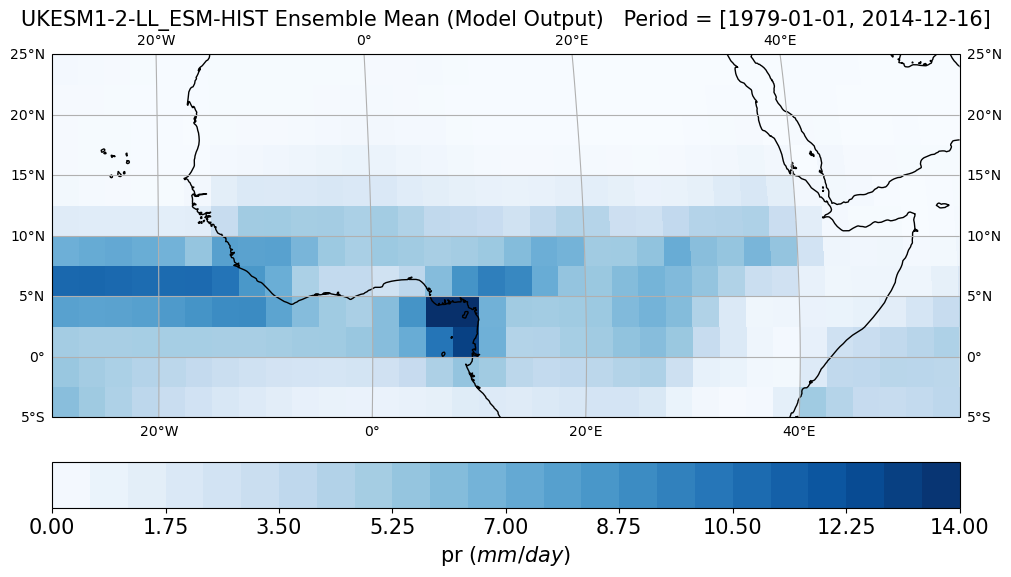

In [29]:
# Mapping extent.
lonmin = -30
lonmax = 55
latmin = -5
latmax = 25

# Function parameters.
unit = 'mm/day'
vmin = 0
vmax = 14
palette = plt.cm.Blues
reg = 'WAM'
seas = 'MJJAS'
var = 'pr'

climatology_map_data = climatology_ens_mean.mean(dim='year')
cbar_label = var+' ($'+unit+'$)'
title = f'UKESM1-2-LL_ESM-HIST Ensemble Mean (Model Output)   Period = [1979-01-01, 2014-12-16]'
Save = True
filename = f'{path_figure}/''WAM_Map-pr_UKESM1-2-LL_ESM-HIST_Ensemble_Mean'+seas+'.png'

# Plot
plot_map_WAM (climatology_map_data, vmin, vmax, cbar_label, palette, lonmin, lonmax, latmin, latmax, title, Save, filename)

### Observations Map

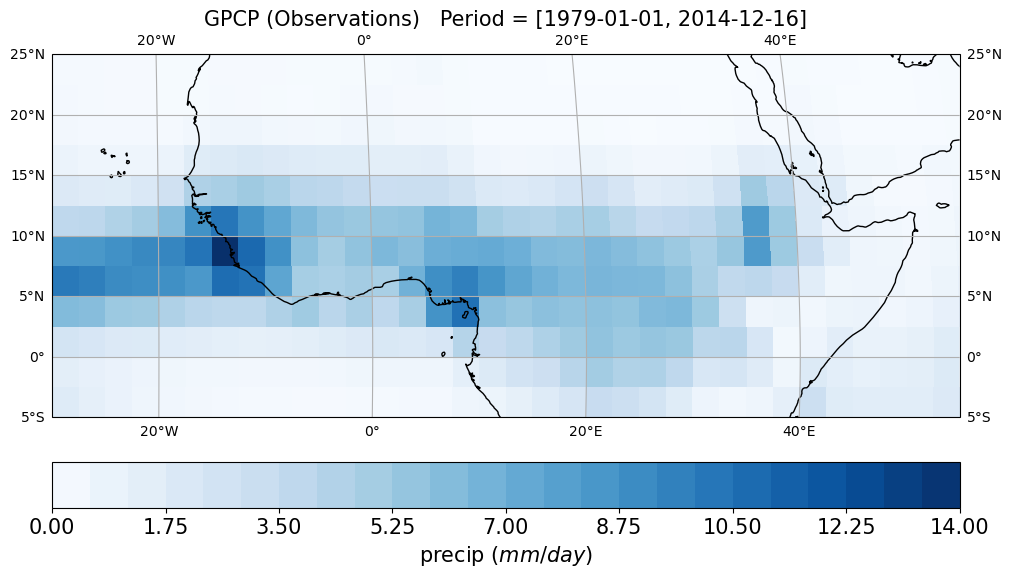

In [30]:
# Plot parameters
lonmin = -30
lonmax = 55
latmin = -5
latmax = 25

# Function parameters
unit = 'mm/day'
vmin = 0
vmax = 14
palette = plt.cm.Blues
reg = 'WAM'
seas = 'MJJAS'
var = 'precip'
obs_map_data = seas_avg_obs[var].mean(dim='year')
cbar_label = var+' ($'+unit+'$)'
title = f'{obs_gen} (Observations)   Period = [1979-01-01, 2014-12-16]'
Save = True 
filename = f'{path_figure}/''WAM_Map-pr_'+f'{obs_gen}_'+seas+'.png'

# Plot
plot_map_WAM_obs (obs_map_data, vmin, vmax, cbar_label, palette, lonmin, lonmax, latmin, latmax, title, Save, filename)

### Bias Map

In [31]:
# Plot parameters
lonmin = -30
lonmax = 55
latmin = -5
latmax = 25

# Function parameters
unit = 'mm/day'
palette = plt.cm.BrBG
reg = 'WAM'
seas = 'MJJAS'
var = 'pr'

# Sampling for t-test
obs_sample = obs_aligned['precip']
int_sample = int_aligned

# Make sure that both datasets are using the same name.
obs_sample = obs_sample.rename({'latitude': 'lat', 'longitude': 'lon'})
int_sample = int_sample.rename({'latitude': 'lat', 'longitude': 'lon'})

# Compute statistics of bias.
bias_data = bias_compute.mean(dim='year')
bias_stats = {}

bias_stats['standard_deviation'] = bias_data.std().compute().item()
bias_stats['min']  = bias_data.min().compute().item()
bias_stats['max']  = bias_data.max().compute().item()

print(bias_stats)

{'standard_deviation': 1.2445948123931885, 'min': -7.419381141662598, 'max': 18.28880500793457}


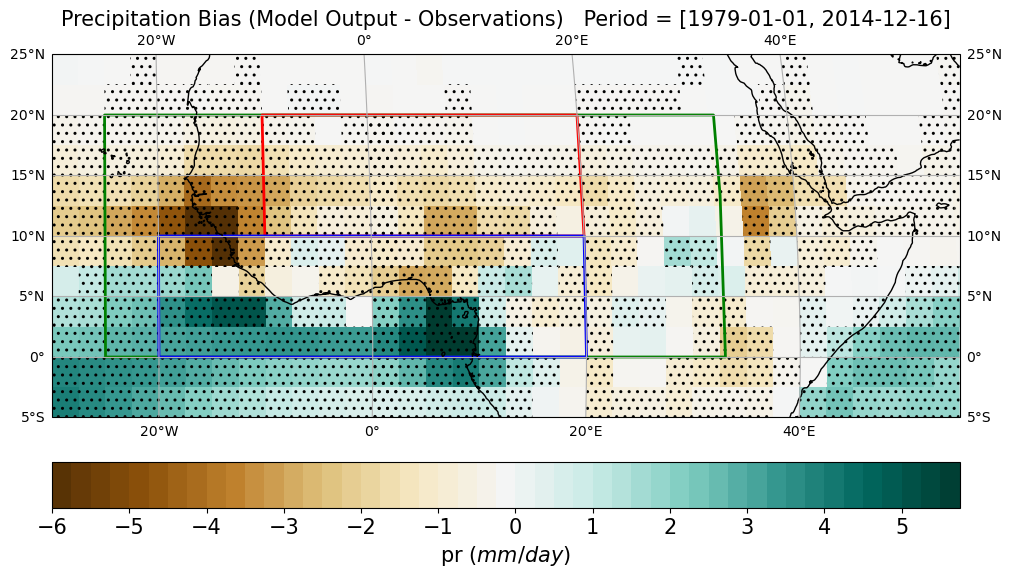

In [32]:
# Data ready for plot.
# bias_data = bias_data.rename({'latitude': 'lat', 'longitude': 'lon'})

vmin = -6
vmax = 6

# Remaining Formatting
cbar_label = var+' ($'+unit+'$)'
title = f'Precipitation Bias (Model Output - Observations)   Period = [1979-01-01, 2014-12-16]'
Save = True 
filename = f'{path_figure}/''WAM_Map-pr_'+'Bias_'+seas+'.png'

# Plot
map_bias_ens(bias_data, vmin, vmax, cbar_label, palette, lonmin, lonmax, latmin, latmax, title, Save, filename, sig_all)

### Statistical Significance Check

In [33]:
bias_ens[ensemble_members[0]]['pr']

<xarray.DataArray 'pr' (year: 35, latitude: 72, longitude: 144)> Size: 1MB
dask.array<sub, shape=(35, 72, 144), dtype=float32, chunksize=(1, 72, 144), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float32 576B 1.25 3.75 6.25 ... 353.8 356.2 358.8
  * latitude   (latitude) float32 288B -88.75 -86.25 -83.75 ... 86.25 88.75
  * year       (year) int64 280B 1979 1980 1981 1982 ... 2010 2011 2012 2013

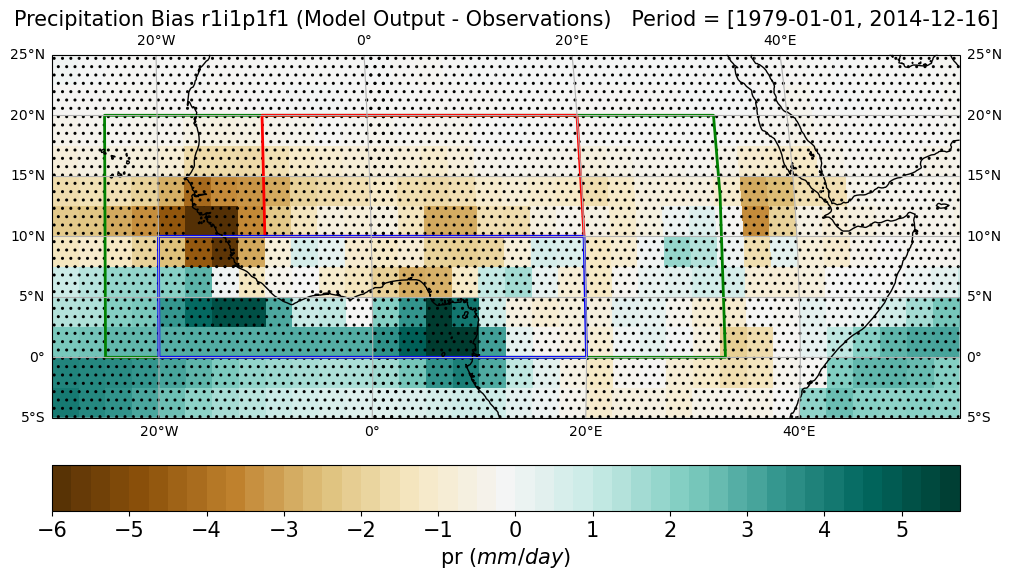

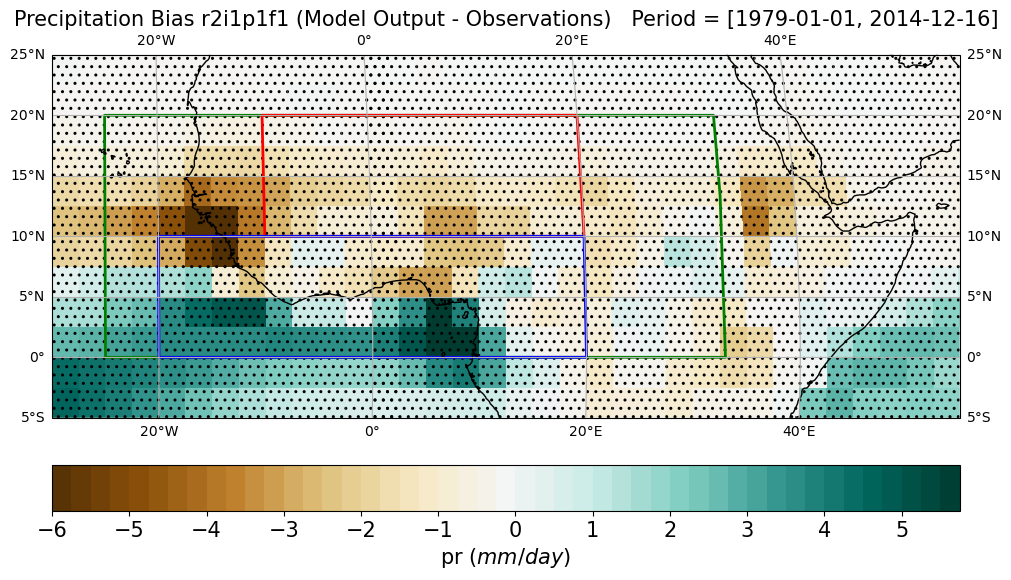

In [ ]:
# Plot parameters
lonmin = -30
lonmax = 55
latmin = -5
latmax = 25

# Function parameters
unit = 'mm/day'
palette = plt.cm.BrBG
reg = 'WAM'
seas = 'MJJAS'
var = 'pr'

vmin = -6
vmax = 6

# Remaining Formatting
cbar_label = var+' ($'+unit+'$)'
Save = False
filename = f'{path_figure}/''WAM_Map-pr_'+'Bias_'+seas+'.png'

for ens in ensemble_members:
    bias_data_ind = bias_ens[ens]['pr'].mean('year')
    title = f'Precipitation Bias {ens} (Model Output - Observations)   Period = [1979-01-01, 2014-12-16]'
    
    map_bias_ens (bias_data_ind, vmin, vmax, cbar_label, palette, lonmin, lonmax, latmin, latmax, title, Save, filename, pvals_dict[ens]['p_value'])

### Final Figure

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig = plt.figure(figsize=(18, 12))

ax1 = fig.add_axes([0.05, 0.55, 0.42, 0.40])   # [left, bottom, width, height]
ax1.imshow(mpimg.imread(f"{path_figure}WAM_Map-pr_GPCP_MJJAS.png"))
ax1.axis("off")

ax2 = fig.add_axes([0.53, 0.55, 0.42, 0.40])
ax2.imshow(mpimg.imread(f"{path_figure}WAM_Map-pr_UKESM1-2-LL_ESM-HIST_Ensemble_MeanMJJAS.png"))
ax2.axis("off")

ax3 = fig.add_axes([0.28, 0.15, 0.44, 0.40])
ax3.imshow(mpimg.imread(f"{path_figure}WAM_Map-pr_Bias_MJJAS.png"))
ax3.axis("off")

plt.savefig(f"{path_figure}WAM_Map-pr_Climatology.png", bbox_inches='tight', pad_inches=0.1, dpi=450)
plt.show()


## Time Series

### Define Boxes

In [ ]:
regions = {"overall": test_poly, "sahel": sahel_poly, "west_coast": coast_poly}

region_colors = {'overall': 'green', 'sahel': 'red', 'west_coast': 'blue'}
region_labels = True

regions_list = ['overall', 'sahel', 'west_coast']
seas_list = ['MJJAS']

In [ ]:
def polygon_mask(ds, polygon, lon_name="longitude", lat_name="latitude"):
    """
    Works for 1-D lon and lat (regular grids).
    Produces mask with dims (lat, lon).
    """

    lon = ds[lon_name].values        # shape (192,)
    lat = ds[lat_name].values        # shape (144,)

    # Build 2D coordinate grid
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Check each grid point
    points = [sgeom.Point(x, y) for x, y in zip(lon2d.ravel(), lat2d.ravel())]
    inside = np.array([polygon.covers(pt) for pt in points])

    mask = inside.reshape(lat2d.shape)   # shape (144, 192)

    # Return DataArray with correct dims and coords
    return xr.DataArray(
        mask,
        dims=(ds[lat_name].dims[0], ds[lon_name].dims[0]),
        coords={ds[lat_name].dims[0]: ds[lat_name],
                ds[lon_name].dims[0]: ds[lon_name]}
    )

### Implementation 4a (Weighted Average)

In [ ]:
# This implementation is also used in the time series with land-sea mask applied.
def area_weighted_avg_masked(data):
    import numpy as np
    
    # Latitude weights: cosine of lat in radians
    lat_rad = np.radians(data['latitude'])
    lat_weights = np.cos(lat_rad)
    
    # Broadcast lat weights to full spatial dims
    # Assuming data dims: ('time', 'lat', 'lon') or similar
    weights = lat_weights.broadcast_like(data.isel(year=0))
    
    # Create a mask of valid (non-NaN) data points
    valid_mask = ~np.isnan(data)
    
    # Apply mask to weights (weights are zero where data is invalid)
    weights_masked = weights * valid_mask
    
    # Normalize weights so they sum to 1 along spatial dims for each time (or other dims)
    weights_sum = weights_masked.sum(dim=['latitude', 'longitude'])
    
    # Avoid division by zero (where weights_sum == 0)
    weights_sum = weights_sum.where(weights_sum != 0)
    
    # Compute weighted average
    weighted_avg = (data * weights_masked).sum(dim=['latitude', 'longitude']) / weights_sum
    return weighted_avg

### Compute Ensemble Mean

In [ ]:
def compute_ensemble_mean(ensemble_list, data_dict, variable='pr'):
    # Collect all DataArrays into a list
    arrays = [data_dict[ens][variable] for ens in ensemble_list]

    # Stack along a new dimension called 'ensemble'
    stacked = xr.concat(arrays, dim='ensemble')

    # Compute ensemble mean
    ens_mean = stacked.mean(dim='ensemble')

    return ens_mean

In [ ]:
time_series_ens_mean = compute_ensemble_mean(ensemble_members, interpolated_model_files)
time_series_ens_mean